# Introduction to PyTorch for Genomic Foundation Models

This notebook provides a hand's on introduction to PyTorch for genomic foundation models. The notebook contains solutions to exercises and hidden solutions that can be revealed when ready.

## 📦 Imports and Device Check

PyTorch uses a **device abstraction** so the same code runs on CPU or GPU.

If a GPU is available, we will use it automatically.


In [13]:
# hide all warnings
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from transformers import AutoTokenizer, AutoModel
    HAS_TRANSFORMERS = True
except:
    HAS_TRANSFORMERS = False

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.9.1+cu128
Using device: cpu


# 🧱 Section 1 — Tensors

Tensors are the **core building block** in PyTorch.

They behave like NumPy arrays but support:

✔ GPU execution  
✔ Automatic differentiation (calculate derivatives, i.e., gradients of functions)  
✔ Linear algebra and deep learning operations (`matmul`, `reshape`, `nn.Linear`, `nn.Conv2d` etc) 

---


In [14]:
x = torch.tensor([1.0, 2.0, 3.0])
x_explicit = x.unsqueeze(1) 
M = torch.randn(2, 3)

print(f"x = {x}")
print(f"M = {M}")
print(f"x.shape = {x.shape}")
print(f"x_explicit.shape = {x_explicit.shape}")
print(f"M.shape = {M.shape}")

# x is treated as a row matching M's columns
print("Matrix multiply M @ x =", M @ x)

x = tensor([1., 2., 3.])
M = tensor([[ 1.2136, -0.6720, -0.1996],
        [ 0.6847,  0.1294, -2.0839]])
x.shape = torch.Size([3])
x_explicit.shape = torch.Size([3, 1])
M.shape = torch.Size([2, 3])
Matrix multiply M @ x = tensor([-0.7290, -5.3083])


### 🎯 Exercise 1 — Try Changing the Tensor

Modify the tensor `x` and re-run the cell. Observe what changes.

---


# 🧠 Section 2 — Automatic Differentiation

PyTorch keeps track of operations to compute **gradients automatically**.

This powers neural network training.


In [15]:
w = torch.tensor(2.0, requires_grad=True)
y = 3*w**2 + 4*w + 1
y.backward()
print("Gradient dy/dw =", w.grad)

Gradient dy/dw = tensor(16.)


### Manual Differentiation Step-by-Step
Let's check if we get the same answer when we differentiate the function manually

<details>

**Function:**  
$y = 3w^2 + 4w + 1$

**Variable Value:**  
$w = 2.0$

#### 1. Apply the Differentiation Rules
We calculate the derivative $\frac{dy}{dw}$ by differentiating each term separately using the **Power Rule** ($\frac{d}{dx}x^n = nx^{n-1}$):

*   **Differentiating $3w^2$:**  
    Multiply the coefficient by the exponent: $3 \times 2 = 6$.  
    Reduce the exponent by one: $w^{(2-1)} = w^1$.  
    **Result: $6w$**

*   **Differentiating $4w$:**  
    Since $w$ is $w^1$, the exponent becomes $0$.  
    **Result: $4$**

*   **Differentiating $1$:**  
    The derivative of a constant is always zero.  
    **Result: $0$**

#### 2. The Gradient Formula
Combining these results gives us the gradient function:
$$\frac{dy}{dw} = 6w + 4$$

#### 3. Evaluate at $w = 2.0$
Now, substitute the value of $w$ provided in the code:
$$\frac{dy}{dw} = 6(2.0) + 4$$
$$\frac{dy}{dw} = 12.0 + 4$$
$$\frac{dy}{dw} = 16.0$$

</details>

# 🏗 Section 3 — Building Your First Model

We now build a **linear regression model** that learns:

$y = 2x + 1$


In [16]:
# Define a simple Linear Regression class inheriting from the base Module
class TinyLinearModel(nn.Module):
    def __init__(self):
        # Initialize the parent class (nn.Module)
        super().__init__()
        # Define a single layer with 1 input and 1 output, including an intercept (bias)
        self.linear = nn.Linear(in_features=1, out_features=1, bias=True)

    # Define the computation graph for the input data
    def forward(self, x):
        return self.linear(x)

# Instantiate the model and move its parameters to the specified hardware (CPU/GPU)
model = TinyLinearModel().to(device)

# Display the model architecture details
model

TinyLinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

<details>
<summary style="font-size: 1.2em; font-weight: bold; color: #2c3e50; cursor: pointer; padding: 10px; background-color: #f0f7ff; border-radius: 5px;">
📐 Click to expand: Why are in_features and out_features both 1 for y = 2x + 1?
</summary>

<br>

| Concept | In $y = 2x + 1$ | What it means |
|--------|-----------------|---------------|
| **in_features** | **1** | You have **1 input variable** ($x$) |
| **out_features** | **1** | You produce **1 output value** ($y$) |

**That's it. It's a direct 1:1 mapping.**

---

### 🧠 Key Insight

**`in_features` = number of independent variables**  
**`out_features` = number of dependent variables**

For $y = 2x + 1$:
- **Independent variables**: just $x$ → **1**
- **Dependent variables**: just $y$ → **1**

**Therefore: `Linear(1, 1)` is the ONLY correct choice.**

</details>

## 📊 Section 4 — Create Synthetic Training Data

We generate noisy data so the model can learn.


In [17]:
# Ensure reproducibility by fixing the random number generator seed
torch.manual_seed(199)

# Create 100 points between -1 and 1, reshaping to (100, 1) for model compatibility
x = torch.linspace(-1, 1, 100).unsqueeze(1).to(device)

# Generate targets using a linear function (y = 2x + 1) plus random Gaussian noise
w = 2
b = 10
y = w*x + b + 0.1*torch.randn_like(x) 

# Wrap tensors into a Dataset object for easier indexing
dataset = TensorDataset(x, y)

# Create an iterable that yields randomized batches of 16 samples for training
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Log dataset statistics to verify shapes and data types
print(f"Total samples: {len(dataset)}")
for i, t in enumerate(dataset.tensors):
    print(f"Tensor {i} shape: {t.shape}") # Expect [100, 1]
    print(f"Tensor {i} dtype: {t.dtype}") # Expect torch.float32


Total samples: 100
Tensor 0 shape: torch.Size([100, 1])
Tensor 0 dtype: torch.float32
Tensor 1 shape: torch.Size([100, 1])
Tensor 1 dtype: torch.float32


## ⚙ Section 5 — Loss and Optimizer

1. The **loss measures error**.
2. The **optimizer updates parameters**.

In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

Check the details about loss function and optimizer below

<details>
<summary><strong>Core Training Components: Criterion and Optimizer</strong></summary>
In PyTorch, the learning process is governed by two main objects: the **Criterion** (which measures error) and the **Optimizer** (which fixes the error).

---

### 1. The Loss Function: `nn.MSELoss()`

This is the criterion that measures how far predictions are from targets and provides gradients for learning.

- **Full Name:** Mean Squared Error (MSE)  
- **Purpose:** Regression tasks (predicting continuous values)  
- **Formula:**  
  $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$  
- **Key Point:** Squaring errors penalizes large mistakes more, which sharpens the focus on big errors but also increases sensitivity to outliers.

***

### 2. The Optimizer: `torch.optim.SGD`

This is the algorithm that updates model weights to reduce the loss.

- **Full Name:** Stochastic Gradient Descent (SGD)  
- **Key Args:**
  - `model.parameters()`: Which weights and biases to update  
  - `lr=0.1`: Learning rate (step-size multiplier)  
- **Update Rule:**  
  $$\text{Weight}_{\text{new}} = \text{Weight}_{\text{old}} - (\text{LearningRate} \times \text{Gradient})$$
- **How it Works:** Uses gradients computed on mini-batches of data to adjust all parameters in the direction that (locally) decreases the loss.
  
---
</details>

# 🚀 Section 6 — Training Loop

This is the core pattern used everywhere, including Hugging Face.


In [19]:
# Iterate through the entire dataset 50 times
for epoch in range(50):
    # Initialize a tracker for the cumulative loss of the current epoch
    loss_sum = 0
    
    # Iterate through randomized mini-batches of inputs (xb) and targets (yb)
    for xb, yb in dataloader:
        # Perform the forward pass: compute predictions using the model
        preds = model(xb)
        
        # Calculate the error between predictions and actual targets
        loss = criterion(preds, yb)
        
        # Clear gradients from the previous step to prevent accumulation
        # take many small, frequent steps toward the minimum
        optimizer.zero_grad()
        
        # Compute gradients of the loss with respect to model parameters
        loss.backward()
        
        # Update model weights based on the computed gradients
        optimizer.step()
        
        # Accumulate the total loss (scaling mean loss by batch size for accuracy)
        loss_sum += loss.item() * xb.size(0)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        # Calculate and display the average loss for the entire dataset
        print(f"Epoch {epoch+1}: loss={loss_sum/len(dataset):.4f}")


Epoch 10: loss=0.0085
Epoch 20: loss=0.0082
Epoch 30: loss=0.0084
Epoch 40: loss=0.0082
Epoch 50: loss=0.0083


### Step-by-Step Training Loop Breakdown
<details>
<summary><strong>Click to see the details</strong></summary>

The training loop is the process of repeatedly showing data to the neural network and adjusting its parameters to minimize error.

#### 1. The Epoch Loop
`for epoch in range(50):`
An **Epoch** is one full cycle through the entire dataset. We repeat this process multiple times so the model can iteratively improve its "guess" through practice.

#### 2. The Mini-Batch Loop
`for xb, yb in dataloader:`
Processing 10,000 images at once is memory-intensive. Instead, we split the data into **Mini-Batches** (small groups). 
*   `xb`: The input features for this specific batch.
*   `yb`: The correct target labels for this specific batch.

#### 3. The Forward Pass
`preds = model(xb)`
The model processes the input data (`xb`) through its layers to produce **predictions** (`preds`). 

#### 4. The Loss Calculation
`loss = criterion(preds, yb)`
We use our "yardstick" (MSELoss) to calculate a single number representing how far the model's predictions were from the actual truth.

#### 5. The Optimization Steps (The "Learning")
*   `optimizer.zero_grad()`: **Reset.** Before calculating new gradients, we must clear out the math from the previous batch so it doesn't accumulate.
*   `loss.backward()`: **Backpropagate.** PyTorch travels backward through the model's math to find out which specific weights caused the error.
*   `optimizer.step()`: **Update.** The optimizer nudges the weights slightly in the direction that will make the loss smaller next time.

#### 6. Accumulating Progress
`loss_sum += loss.item() * xb.size(0)`
Because `loss` is the average for a single batch, we multiply it by the number of samples in that batch (`xb.size(0)`) to track the total error across the entire epoch.

#### 7. Monitoring
`print(f"Epoch {epoch+1}: loss={loss_sum/len(dataset):.4f}")`
Every 10 epochs, we print the **Average Loss** (Total Loss / Total Samples). 
*   **A decreasing loss** means the model is successfully learning.
*   **A stagnant loss** means the model has finished training or needs a different learning rate.
  
</details>

## 🔍 Section 7 — Inspect Learned Parameters

In [20]:
w_hat = model.linear.weight.item()
b_hat = model.linear.bias.item()
print(f"learned parameters: w_hat = {w_hat}, b_hat = {b_hat}")
print(f"True parameters: w = {w}, b = {b}")

learned parameters: w_hat = 2.006497859954834, b_hat = 9.985382080078125
True parameters: w = 2, b = 10


<details>
<summary style="font-size: 1.2em; font-weight: bold; color: #2c3e50; cursor: pointer; padding: 10px; background-color: #f0f7ff; border-radius: 5px;">
📐 Change the value of `w` and `b` in synthetic data generation, re-train and check the results?
</summary>
</details>

# 🧪 Section 8 — Optional Interactive Classification Demo

We train a tiny classifier to learn a relatively challenging dataset

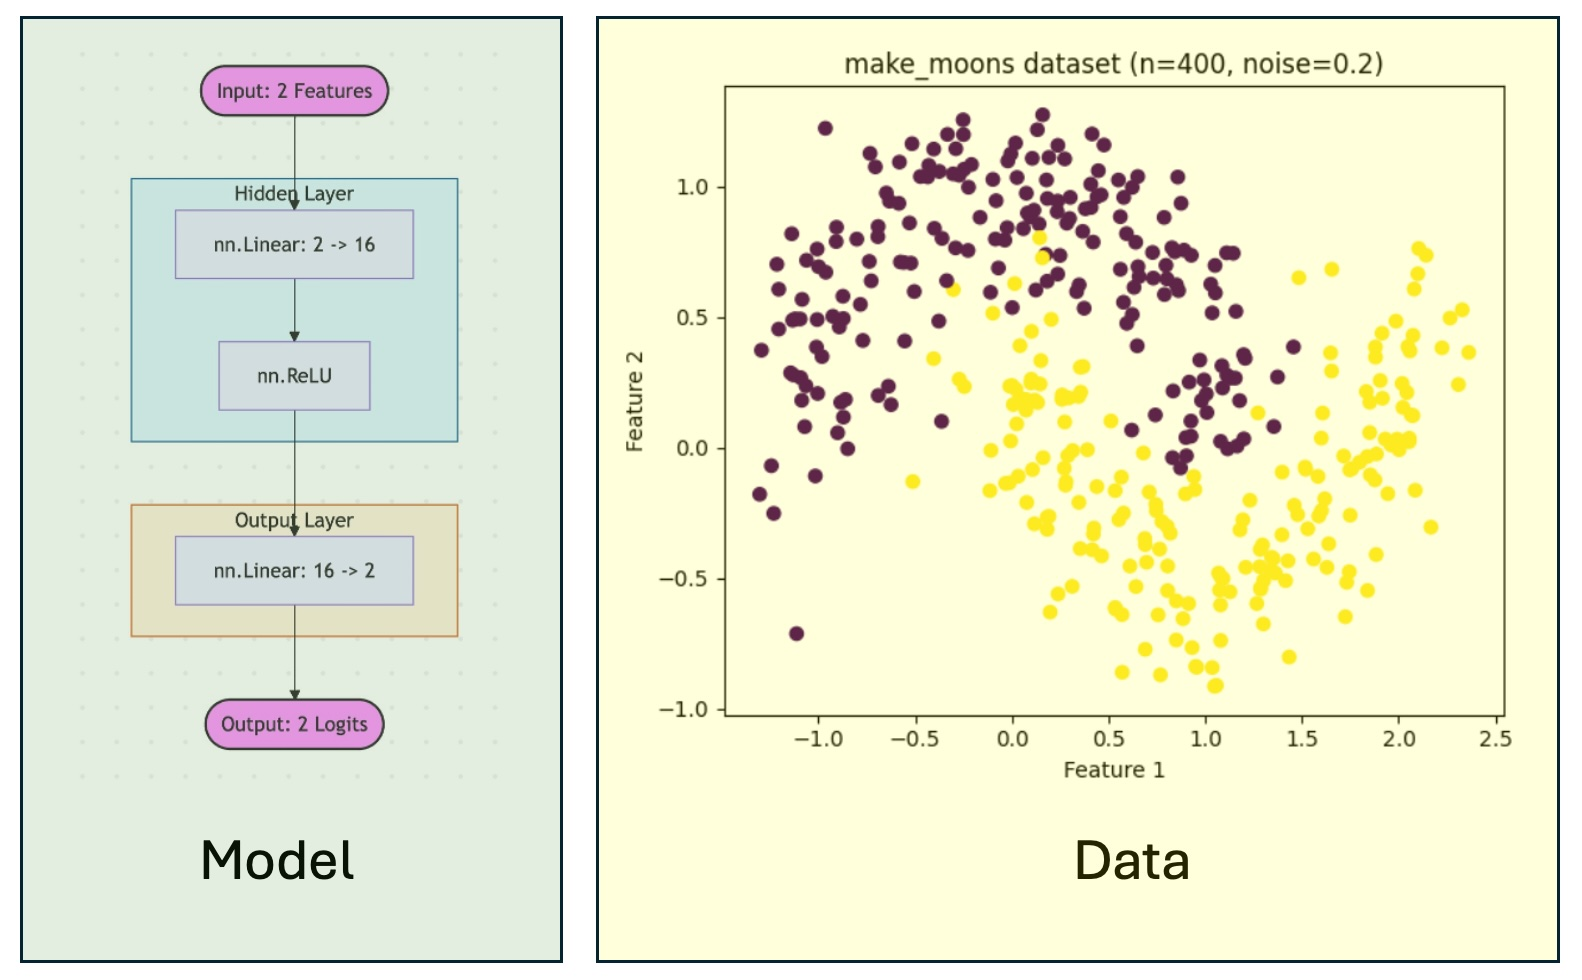

In [28]:
from IPython.display import Image, display
display(Image(filename='../../images/classifier_and_data.jpg', width=700, height=300))

Training samples: 400, Test samples: 100

--- Training ---
Epoch 5: train_accuracy=0.875
Epoch 10: train_accuracy=0.882
Epoch 15: train_accuracy=0.907
Epoch 20: train_accuracy=0.935


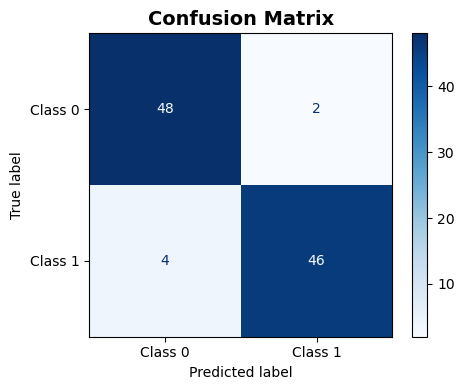


         TEST RESULTS SUMMARY
  Accuracy:  94.0% (94/100)
  Precision: 95.8%
  Recall:    92.0%
  F1 Score:  93.9%


In [29]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

# Generate synthetic moon-shaped data
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# Create data loader for training
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

# Define a simple 2-layer classifier
class TinyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        return self.net(x)

clf = TinyClassifier().to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-2)

# Training loop
print("\n--- Training ---")
for epoch in range(20):
    correct = 0
    total = 0
    for xb, yb in loader:
        logits = clf(xb)
        loss = F.cross_entropy(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        correct += (logits.argmax(1)==yb).sum().item()
        total += xb.size(0)
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}: train_accuracy={correct/total:.3f}")

# Evaluate on test data
clf.eval()  # Set model to evaluation mode
with torch.no_grad():
    test_logits = clf(X_test)
    test_preds = test_logits.argmax(dim=1)
    test_correct = (test_preds == y_test).sum().item()
    test_accuracy = test_correct / len(y_test)

# Get predictions for visualization
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

y_test_np = y_test.cpu().numpy()
test_preds_np = test_preds.cpu().numpy()

# Create figure with confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))

# Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test_np, test_preds_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary metrics
print("\n" + "="*40)
print("         TEST RESULTS SUMMARY")
print("="*40)
print(f"  Accuracy:  {test_accuracy:.1%} ({test_correct}/{len(y_test)})")
print(f"  Precision: {precision_score(y_test_np, test_preds_np):.1%}")
print(f"  Recall:    {recall_score(y_test_np, test_preds_np):.1%}")
print(f"  F1 Score:  {f1_score(y_test_np, test_preds_np):.1%}")
print("="*40)

# 🔗 Section 9 — Connecting to Hugging Face Genomic LLMs

This demonstrates how pretrained models still use PyTorch tensors under the hood.


In [32]:
from transformers import AutoTokenizer, AutoModel
model_name = "RaphaelMourad/Mistral-DNA-v1-17M-hg38"

print(f"Loading Model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model_hf = AutoModel.from_pretrained(model_name, trust_remote_code=True).to(device)
print(model_hf)
print(f"Model loaded successfully on device: {device}\n")
print("")

# 1. Prepare Input
seq = "ACGTTAAGTTGAGAGGTCCTTACCTAGT"
print(f"Input DNA Sequence (Length {len(seq)}): {seq[:20]}...")

# 2. Tokenization
inputs = tokenizer(seq, return_tensors="pt").to(device)
print(f"Tokenized IDs (Input IDs): {inputs['input_ids']}")
print(f"Number of tokens created: {inputs['input_ids'].shape[1]}\n")

# 3. Inference
print("--- Running Forward Pass ---")
with torch.no_grad():
    outputs = model_hf(**inputs)

# 4. Explain Output Shape
shape = outputs.last_hidden_state.shape
print(f"Output Shape: {shape}")
print(f"Interpretation: {shape[0]} Sequence | {shape[1]} Tokens | {shape[2]} Hidden Dimensions (Embedding Size)")

# Accessing the vector for the first token
first_token_vector = outputs.last_hidden_state[0, 0, :5]
print(f"First 5 values of the first token's embedding: {first_token_vector}")


Loading Model: RaphaelMourad/Mistral-DNA-v1-17M-hg38
MixtralModel(
  (embed_tokens): Embedding(4096, 256)
  (layers): ModuleList(
    (0-7): 8 x MixtralDecoderLayer(
      (self_attn): MixtralAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (o_proj): Linear(in_features=256, out_features=256, bias=False)
      )
      (block_sparse_moe): MixtralSparseMoeBlock(
        (gate): Linear(in_features=256, out_features=8, bias=False)
        (experts): ModuleList(
          (0-7): 8 x MixtralBlockSparseTop2MLP(
            (w1): Linear(in_features=256, out_features=256, bias=False)
            (w2): Linear(in_features=256, out_features=256, bias=False)
            (w3): Linear(in_features=256, out_features=256, bias=False)
            (act_fn): SiLUActivation()
          )
        )
      )
      (input_layerno

> “The model’s hidden size (`embedding size` / `d_model`) is **256**, shown by `Embedding(..., 256)` and confirmed by the output shape `[batch, tokens, hidden]`.”


# 🎯 Final Summary

You should now be comfortable with basic concepts of:

✔ Tensors  
✔ Autograd  
✔ Model building  
✔ Training loops  
✔ Hugging Face integration  

These are the foundations that will be used in **genomic foundation model fine‑tuning**.

----------------